Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.9240 - loss: 0.2509 - val_accuracy: 0.9845 - val_loss: 0.0489
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9745 - loss: 0.0888 - val_accuracy: 0.9851 - val_loss: 0.0440
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9807 - loss: 0.0635 - val_accuracy: 0.9900 - val_loss: 0.0303
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9837 - loss: 0.0545 - val_accuracy: 0.9904 - val_loss: 0.0263
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9868 - loss: 0.0439 - val_accuracy: 0.9911 - val_loss: 0.0268
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9889 - loss: 0.0381 - val_accuracy: 0.9913 - val_loss: 0.0267
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9899 - loss: 0.0329 - val_accuracy: 0.9918 - val_loss: 0.0243
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9909 - loss: 0.0306 - 

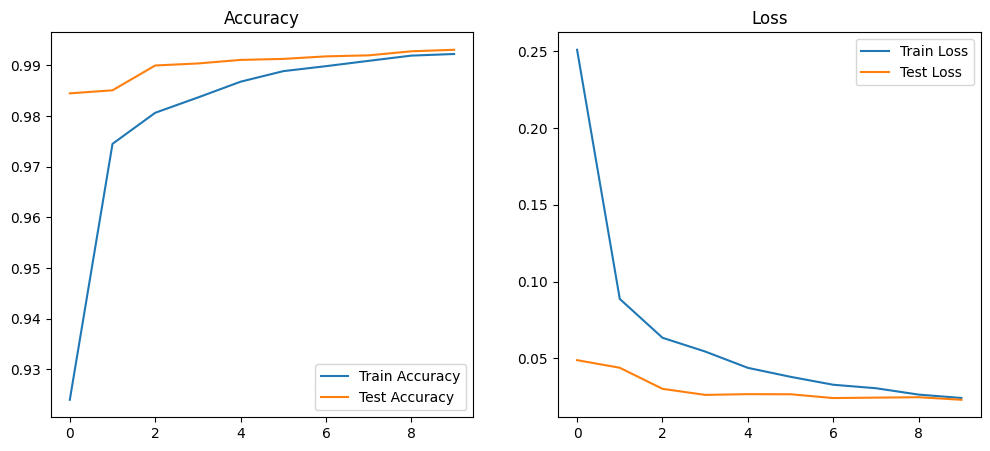

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


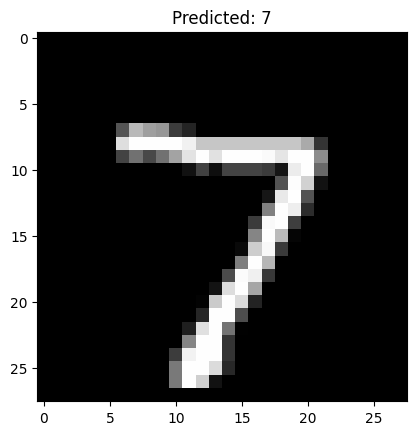

In [4]:
# ==========================================
# MNIST Handwritten Digit Recognition (Full Version)
# ==========================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Load Dataset
# ==========================================
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# ==========================================
# 2. Preprocessing
# ==========================================
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# ==========================================
# 3. Build CNN Model
# ==========================================
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(10, activation='softmax')
])

# ==========================================
# 4. Compile Model
# ==========================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 5. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# ==========================================
# 6. Evaluate Model
# ==========================================
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

# ==========================================
# 7. Plot Accuracy & Loss Graphs
# ==========================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title("Loss")
plt.legend()

plt.show()

# ==========================================
# 8. Save Model
# ==========================================
model.save("mnist_model.h5")

# ==========================================
# 9. Load Model
# ==========================================
loaded_model = keras.models.load_model("mnist_model.h5")

# ==========================================
# 10. Predict Sample Image
# ==========================================
def predict_digit(index):
    img = X_test[index]
    prediction = loaded_model.predict(img.reshape(1,28,28,1))
    digit = np.argmax(prediction)
    
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Predicted: {digit}")
    plt.show()

# Example Prediction
predict_digit(0)